In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

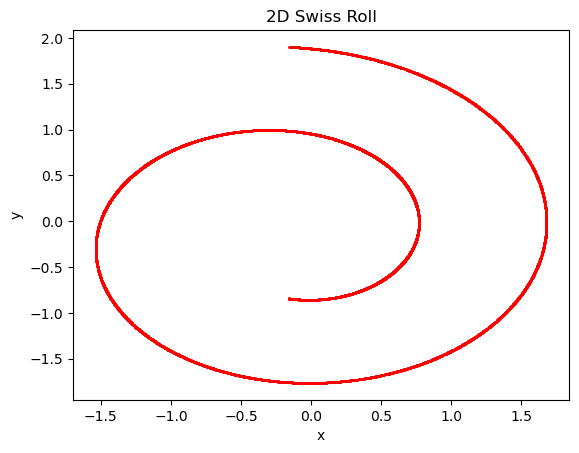

In [2]:
X, t = make_swiss_roll(n_samples=10000, noise=0.0)

X=X[:,[0,2]]

X = (X-X.mean())/X.std()

plt.scatter(X[:,0], X[:,1], s=1, color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Swiss Roll")
X = torch.tensor(X, dtype=torch.float32)
dataset = TensorDataset(X)

loader = DataLoader(dataset, batch_size=100, shuffle=True)



In [3]:
for batch in loader:
    x = batch[0]

model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

optimizer = optim.Adam(
    model.parameters(),
    lr=5e-4
)

sigma = 0.05
num_epochs = 5000




for epoch in range(num_epochs):
    
    epoch_loss =0.0

    for batch in loader:
        eps = torch.randn_like(x)

        x_noisy = x + sigma*eps

        score_pred = model(x_noisy)

        target = -eps/sigma

        loss = ((score_pred-target)**2).mean()


        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 

        epoch_loss += loss.item()

    if epoch % 10 ==0:
        print(f"Epoch {epoch}: {epoch_loss/len(loader):.4f}")

        

Epoch 0: 403.6816
Epoch 10: 397.7745
Epoch 20: 388.0930
Epoch 30: 389.0121
Epoch 40: 364.2431
Epoch 50: 354.3745
Epoch 60: 343.6122
Epoch 70: 329.7282
Epoch 80: 312.1542
Epoch 90: 310.6101
Epoch 100: 298.4668
Epoch 110: 293.8518
Epoch 120: 280.9411
Epoch 130: 270.8263
Epoch 140: 260.1033
Epoch 150: 253.4446
Epoch 160: 246.2622
Epoch 170: 243.9692
Epoch 180: 232.6853
Epoch 190: 234.8671
Epoch 200: 219.6385
Epoch 210: 218.0736
Epoch 220: 210.3516
Epoch 230: 213.1776
Epoch 240: 209.6845
Epoch 250: 207.6822
Epoch 260: 206.2402
Epoch 270: 200.6432
Epoch 280: 201.0359
Epoch 290: 197.4521
Epoch 300: 198.5675
Epoch 310: 198.8654
Epoch 320: 196.4590
Epoch 330: 195.6787
Epoch 340: 192.5021
Epoch 350: 189.9458
Epoch 360: 192.0748
Epoch 370: 186.6018
Epoch 380: 191.3902
Epoch 390: 184.7127
Epoch 400: 189.1712
Epoch 410: 190.1156
Epoch 420: 185.8149
Epoch 430: 186.0139
Epoch 440: 187.5374
Epoch 450: 186.4771
Epoch 460: 189.2834
Epoch 470: 180.7637
Epoch 480: 184.3089
Epoch 490: 181.1410
Epoch 500: 

In [4]:
x_min, x_max = -2, 2
y_min, y_max = -2, 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 30),
    np.linspace(y_min, y_max, 30)
)

grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid = torch.tensor(grid, dtype=torch.float32)

In [5]:
model.eval()

with torch.no_grad():
    scores = model(grid).cpu().numpy()

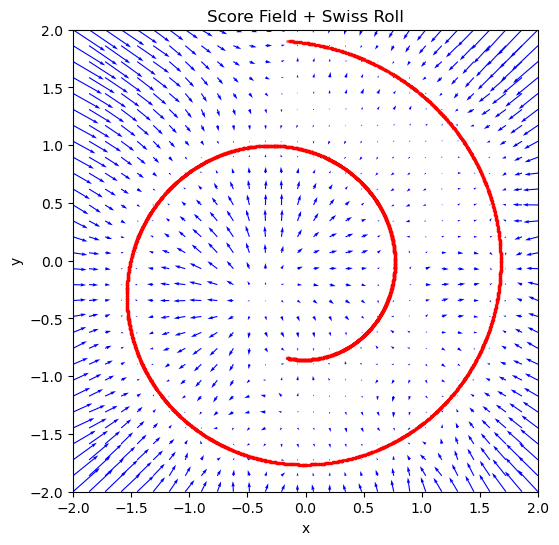

In [6]:
plt.figure(figsize=(6,6))

plt.quiver(
    grid[:, 0].numpy(),
    grid[:, 1].numpy(),
    scores[:, 0],
    scores[:, 1],
    color="blue"
)
X_np = X.detach().numpy()

plt.scatter(X_np[:, 0], X_np[:, 1], s=2, alpha=0.3, color="red")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Score Field + Swiss Roll")
plt.show()

In [7]:
n_samples = 5000

x_samples = torch.randn(n_samples, 2)

eta = 0.001

n_steps = 500

trajectory = []

for k in range(n_steps):

    trajectory.append(x_samples.detach().cpu().numpy())
    score = model(x_samples)
    noise = torch.randn_like(x_samples)

    x_samples = x_samples + eta*score + np.sqrt(2*eta)*noise

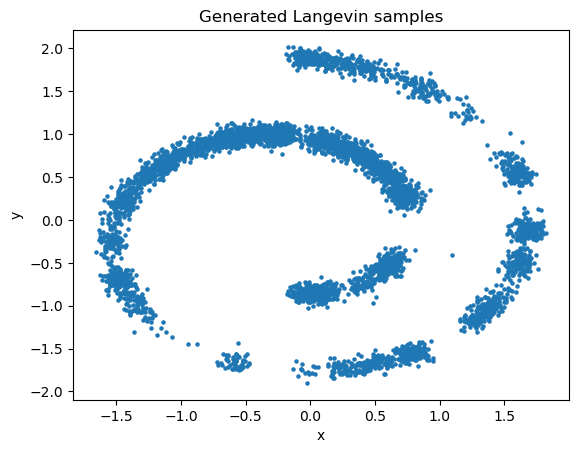

In [8]:
samples = x_samples.detach().cpu().numpy()

plt.figure()
plt.scatter(samples[:,0], samples[:,1], s=5)
plt.title("Generated Langevin samples")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

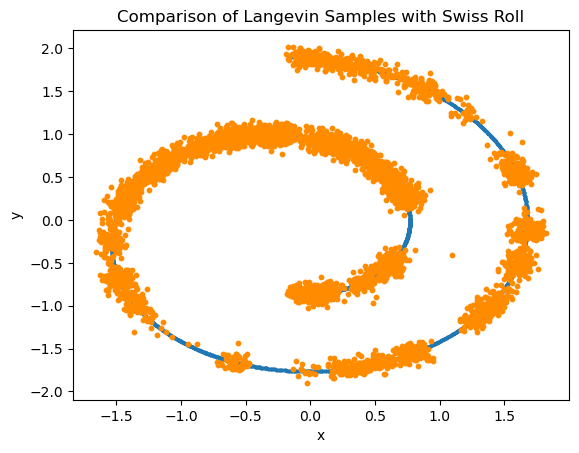

In [12]:
plt.figure()

plt.scatter(X_np[:,0], X_np[:,1], s=2)
plt.scatter(samples[:,0], samples[:,1], s=10,c='darkorange')
plt.title("Comparison of Langevin Samples with Swiss Roll")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Text(0.5, 0, 'X-Coordinate')

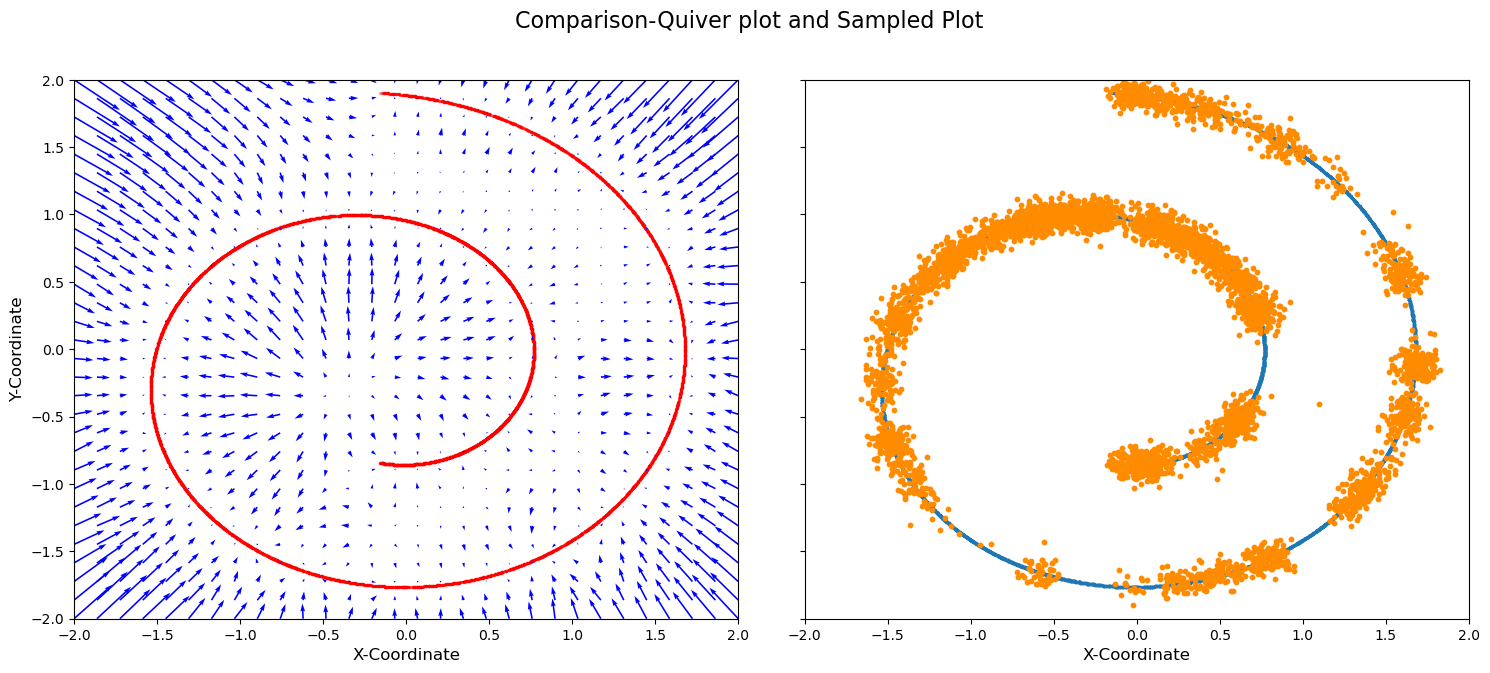

In [13]:
fig, axs = plt.subplots(1,2,sharey=True,figsize=(18,7))
plt.subplots_adjust(wspace=0.1)
fig.suptitle('Comparison-Quiver plot and Sampled Plot',fontsize=16)
axs[0].scatter(X_np[:, 0], X_np[:, 1], s=2, alpha=0.3, color="red")
axs[0].quiver(grid[:, 0].numpy(),
    grid[:, 1].numpy(),
    scores[:, 0],
    scores[:, 1],
    color="blue"
)
axs[1].scatter(X_np[:,0], X_np[:,1], s=2)
axs[1].scatter(samples[:,0], samples[:,1], s=10,c='darkorange')
axs[0].set_xlim(-2,2)
axs[1].set_xlim(-2,2)
axs[0].set_ylim(-2,2)
axs[1].set_ylim(-2,2)
axs[0].set_ylabel("Y-Coordinate",fontsize=12)
axs[0].set_xlabel("X-Coordinate",fontsize=12)
axs[1].set_xlabel("X-Coordinate",fontsize=12)